<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Skin_Cancer_Classification_Using_Spiking_Neural_Networks_on_the_ISIC_9_Class_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install snntorch torchvision seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 4.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import snntorch as snn
from snntorch import spikegen
from snntorch import functional as SF

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from PIL import Image

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [3]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
train_data = ImageFolder(
    '/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train',
    transform=transform
)

test_data = ImageFolder(
    '/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test',
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

classes = train_data.classes
num_classes = len(classes)

print("Classes:", classes)
print("Number of Classes:", num_classes)

Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Number of Classes: 9


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

num_steps = 50
beta = 0.9

epochs = 25
lr = 0.0005

In [6]:
class ImprovedSNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snn.Leaky(beta=beta)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snn.Leaky(beta=beta)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2)
        self.lif3 = snn.Leaky(beta=beta)

        self.fc1 = nn.Linear(
            64 * 4 * 4,
            num_classes
        )

        self.lif4 = snn.Leaky(beta=beta)

    def forward(self, x):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        spk_out = []

        for t in range(num_steps):

            cur1 = self.pool1(
                self.conv1(x[t])
            )

            spk1, mem1 = self.lif1(
                cur1,
                mem1
            )

            cur2 = self.pool2(
                self.conv2(spk1)
            )

            spk2, mem2 = self.lif2(
                cur2,
                mem2
            )

            cur3 = self.pool3(
                self.conv3(spk2)
            )

            spk3, mem3 = self.lif3(
                cur3,
                mem3
            )

            cur4 = self.fc1(
                spk3.view(
                    spk3.size(0),
                    -1
                )
            )

            spk4, mem4 = self.lif4(
                cur4,
                mem4
            )

            spk_out.append(spk4)

        return torch.stack(spk_out)

In [7]:
model = ImprovedSNN().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=lr
)

loss_fn = SF.ce_rate_loss()

In [8]:
train_acc = []
test_acc = []

train_loss = []
test_loss = []

In [9]:
for epoch in range(epochs):

    model.train()

    correct = 0
    total = 0

    running_loss = 0

    for data, targets in train_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = spikegen.rate(
            data,
            num_steps=num_steps
        )

        optimizer.zero_grad()

        spk_out = model(data)

        loss = loss_fn(
            spk_out,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pred = spk_out.sum(
            dim=0
        ).argmax(dim=1)

        correct += (
            pred == targets
        ).sum().item()

        total += targets.size(0)

    train_accuracy = (
        100 * correct / total
    )

    avg_train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc.append(
        train_accuracy
    )

    train_loss.append(
        avg_train_loss
    )

    model.eval()

    correct = 0
    total = 0

    running_loss = 0

    with torch.no_grad():

        for data, targets in test_loader:

            data = data.to(device)
            targets = targets.to(device)

            data = spikegen.rate(
                data,
                num_steps=num_steps
            )

            spk_out = model(data)

            loss = loss_fn(
                spk_out,
                targets
            )

            running_loss += loss.item()

            pred = spk_out.sum(
                dim=0
            ).argmax(dim=1)

            correct += (
                pred == targets
            ).sum().item()

            total += targets.size(0)

    testing_accuracy = (
        100 * correct / total
    )

    avg_test_loss = (
        running_loss /
        len(test_loader)
    )

    test_acc.append(
        testing_accuracy
    )

    test_loss.append(
        avg_test_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Acc: {testing_accuracy:.2f}% | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Test Loss: {avg_test_loss:.4f}"
    )

Epoch 1/25 | Train Acc: 20.14% | Test Acc: 15.25% | Train Loss: 2.0724 | Test Loss: 2.2596
Epoch 2/25 | Train Acc: 21.04% | Test Acc: 24.58% | Train Loss: 2.0457 | Test Loss: 2.2492
Epoch 3/25 | Train Acc: 21.35% | Test Acc: 22.88% | Train Loss: 2.0377 | Test Loss: 2.2333
Epoch 4/25 | Train Acc: 21.17% | Test Acc: 20.34% | Train Loss: 2.0310 | Test Loss: 2.2307
Epoch 5/25 | Train Acc: 21.93% | Test Acc: 22.03% | Train Loss: 2.0327 | Test Loss: 2.2193
Epoch 6/25 | Train Acc: 21.57% | Test Acc: 17.80% | Train Loss: 2.0289 | Test Loss: 2.2159
Epoch 7/25 | Train Acc: 22.29% | Test Acc: 20.34% | Train Loss: 2.0269 | Test Loss: 2.1717
Epoch 8/25 | Train Acc: 20.46% | Test Acc: 15.25% | Train Loss: 2.0214 | Test Loss: 2.1837
Epoch 9/25 | Train Acc: 20.95% | Test Acc: 20.34% | Train Loss: 2.0190 | Test Loss: 2.1726
Epoch 10/25 | Train Acc: 21.35% | Test Acc: 20.34% | Train Loss: 2.0141 | Test Loss: 2.1836
Epoch 11/25 | Train Acc: 21.13% | Test Acc: 15.25% | Train Loss: 2.0143 | Test Loss: 2.18

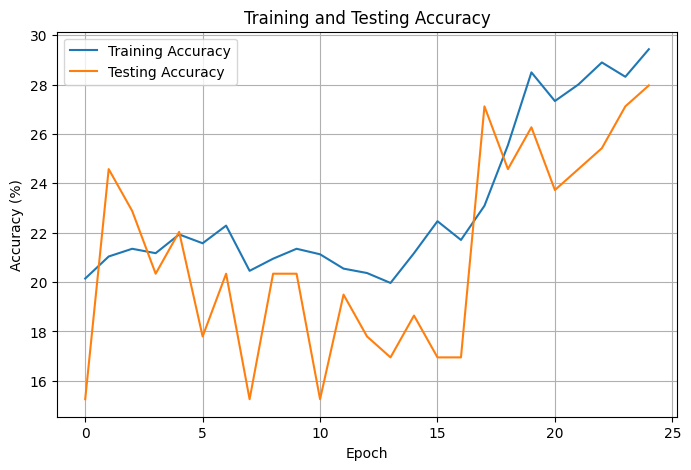

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    train_acc,
    label="Training Accuracy"
)

plt.plot(
    test_acc,
    label="Testing Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training and Testing Accuracy"
)

plt.legend()
plt.grid()

plt.show()

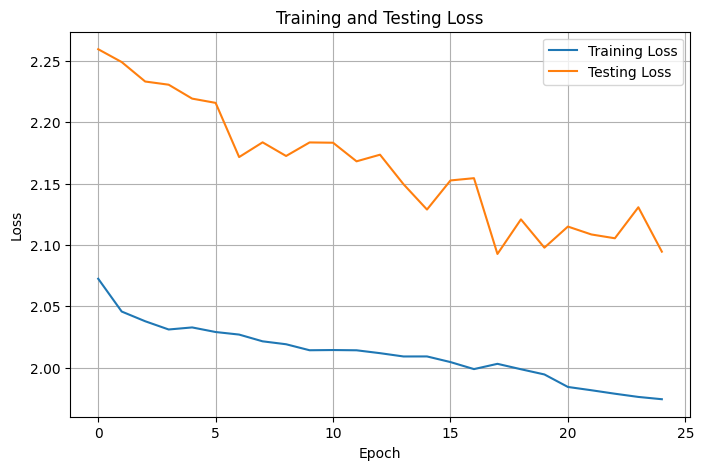

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    train_loss,
    label="Training Loss"
)

plt.plot(
    test_loss,
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Testing Loss"
)

plt.legend()
plt.grid()

plt.show()

In [12]:
model.eval()

correct = 0
total = 0

running_loss = 0

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for data, targets in test_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = spikegen.rate(
            data,
            num_steps=num_steps
        )

        spk_out = model(data)

        loss = loss_fn(
            spk_out,
            targets
        )

        running_loss += loss.item()

        spike_counts = spk_out.sum(dim=0)

        probs = torch.softmax(
            spike_counts,
            dim=1
        )

        preds = probs.argmax(
            dim=1
        )

        correct += (
            preds == targets
        ).sum().item()

        total += targets.size(0)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            targets.cpu().numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

final_test_acc = (
    100 * correct / total
)

final_test_loss = (
    running_loss /
    len(test_loader)
)

print(
    f"Test Accuracy: "
    f"{final_test_acc:.2f}%"
)

print(
    f"Test Loss: "
    f"{final_test_loss:.4f}"
)

Test Accuracy: 31.36%
Test Loss: 2.0968


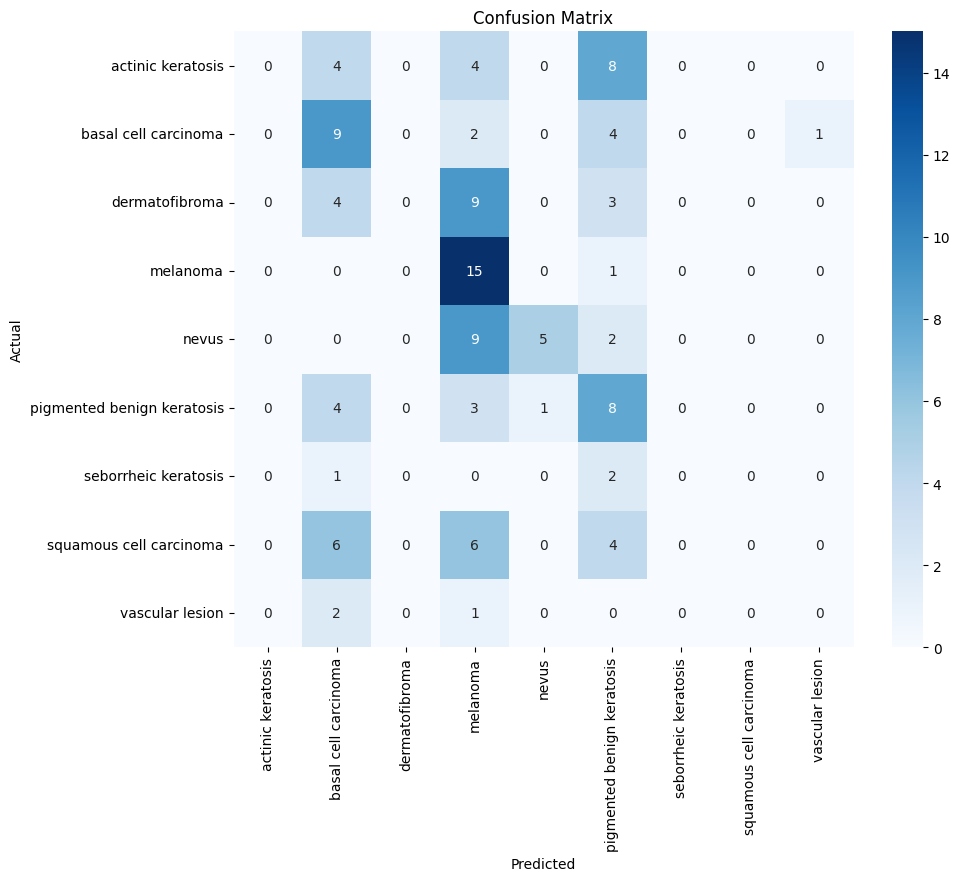

In [13]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [14]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=classes
    )
)

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.30      0.56      0.39        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.31      0.94      0.46        16
                     nevus       0.83      0.31      0.45        16
pigmented benign keratosis       0.25      0.50      0.33        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.31       118
                 macro avg       0.19      0.26      0.18       118
              weighted avg       0.23      0.31      0.22       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

print(
    "Weighted F1 Score:",
    f1
)

Weighted F1 Score: 0.22247072504994392


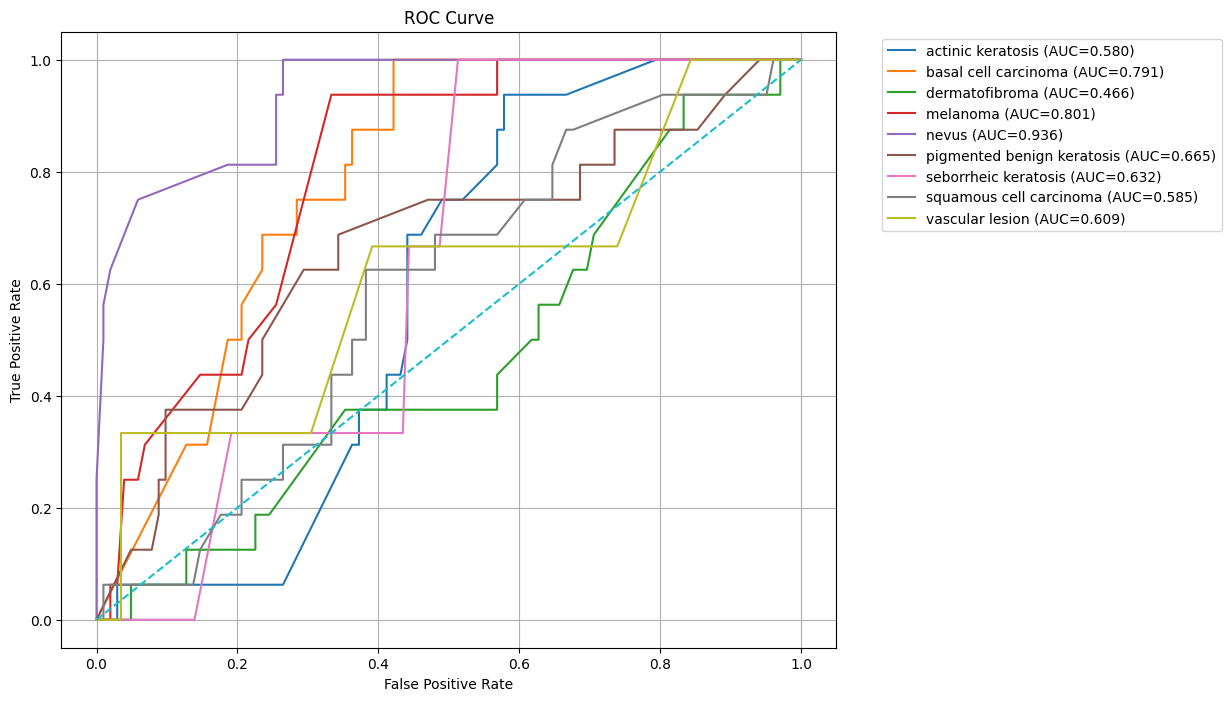

In [16]:
all_labels_bin = label_binarize(
    all_labels,
    classes=np.arange(num_classes)
)

all_probs = np.array(
    all_probs
)

plt.figure(figsize=(10,8))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        all_labels_bin[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{classes[i]} "
              f"(AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid()
plt.show()

In [17]:
roc_auc = roc_auc_score(
    all_labels_bin,
    all_probs,
    multi_class="ovr",
    average="weighted"
)

print(
    "Weighted ROC-AUC Score:",
    roc_auc
)

Weighted ROC-AUC Score: 0.6856611325443959


In [24]:
from google.colab import files

uploaded = files.upload()

def predict_image(path):

    img = Image.open(path).convert('L')

    img = transform(img)

    img = img.unsqueeze(0)

    img = img.to(device)

    img = spikegen.rate(
        img,
        num_steps=num_steps
    )

    with torch.no_grad():

        spk_out = model(img)

        pred = spk_out.sum(
            dim=0
        ).argmax(dim=1)

    return classes[
        pred.item()
    ]

for file in uploaded.keys():

    print(
        "Prediction:",
        predict_image(file)
    )

Saving ISIC_0000002.jpg to ISIC_0000002.jpg
Prediction: melanoma
